# Comparative Time Series Analysis of SARIMA dan XGBoost Models for Food Raw Material Import Value

## Business Understanding

Predicting the import value of 5 food raw material commodities group based on 2-digit HS Codes:
* HS 04 (Milk, Butter, and egg)
* HS 07 (Vegetables)
* HS 10 (Cereals)
* HS 12 (Oil seeds and oleaginous fruits)
* HS 17 (Sugars and sugar confectionery)

Background:
* Reliance of F&B businesses in Indonesia on imported food raw materials
* Fluctuations on import values impact production costs and business profit margins
* USD values ​​reflect the actual financial burden faced by businesses
* A need to understand future import value trends to formulate optimal procurement strategies

## Data Understanding 1 (Raw Data)

Import value data was obtained from BPS for the period January 2014 - May 2026, in the form of monthly data by HS code.

### Import Libraries

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import matplotlib.ticker as ticker

Mounted at /content/drive


### Load data

In [2]:
df_2014_2016 = pd.read_excel('/content/drive/MyDrive/TA/data/bps_2014_2016.xlsx', header=None)
df_2014_2016.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,"Impor HS 2 Digit Tahun 2016,2015,2014",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Bulan,[01] Januari,[02] Februari,[03] Maret,[04] April,[05] Mei,[06] Juni,[07] Juli,[08] Agustus,[09] September,[10] Oktober,[11] November,[12] Desember,Totals
2,Kode HS,Tahun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[04] Produk susu; telur unggas; madu alam; pro...,2014,NaN,77115100.00,107389161.00,136648208.00,159130719.00,127602341.00,148197241.00,77491722.00,104288352.00,131981821.00,113795305.00,84121259.00,106461996.00,1374223225.00
4,NaN,2015,NaN,66196252.00,95365181.00,95238110.00,88797372.00,84483370.00,94572152.00,38972506.00,76282971.00,65779346.00,75840941.00,65230271.00,64948391.00,911706863.00


In [3]:
df_2017_2021 = pd.read_excel('/content/drive/MyDrive/TA/data/bps_2017_2021.xlsx', header=None)
df_2017_2021.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,"Impor HS 2 Digit Tahun 2021,2020,2019,2018,2017",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Bulan,[01] Januari,[02] Februari,[03] Maret,[04] April,[05] Mei,[06] Juni,[07] Juli,[08] Agustus,[09] September,[10] Oktober,[11] November,[12] Desember,Totals
2,Kode HS,Tahun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[04] Produk susu; telur unggas; madu alam; pro...,2017,NaN,63362910.00,91220204.00,85710820.00,78726828.00,93870008.00,68304940.00,66217605.00,96757767.00,71408568.00,94076666.00,91951948.00,88909186.00,990517450.00
4,NaN,2018,NaN,71438715.00,79305967.00,82470785.00,99433194.00,95071200.00,54367379.00,51626178.00,100195264.62,75976656.00,94035106.00,100206250.00,110352550.00,1014479244.62


In [4]:
df_2022_2026 = pd.read_excel('/content/drive/MyDrive/TA/data/bps_2022_2026.xlsx', header=None)
df_2022_2026.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,"Impor HS 2 Digit Tahun 2026,2025,2024,2023,2022",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Bulan,[01] Januari,[02] Februari,[03] Maret,[04] April,[05] Mei,[06] Juni,[07] Juli,[08] Agustus,[09] September,[10] Oktober,[11] November,[12] Desember,Totals
2,Kode HS,Tahun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[04] Milk butter and egg,2022,NaN,86826504.00,136636357.00,199833604.00,174331585.00,166313771.00,185730922.00,134834632.00,242908259.00,162021759.00,160142502.00,173576851.00,166063105.00,1989219851.00
4,NaN,2023,NaN,110054343.00,133614861.00,144031902.00,131517410.00,151500355.00,126588557.00,123191572.00,135785340.00,102458609.00,97567270.00,117008582.00,101009224.00,1474328025.00


Understanding Results
* These data still have a format that is less than ideal for time series analysis.
* Data is grouped per HS Code, then there are 3 rows per year.
* Columns for January-December are arranged horizontally and added with a 'Totals' column at the end
* There is a 'Totals' row at the bottom that needs to be removed

## Data Preparation 1 (Reshape Raw Data)

### Reshape

In [6]:
def parse_bps_file(filepath):
  df = pd.read_excel(filepath, header=None)

  # Used data row
  df = df.iloc[3:-1].reset_index(drop=True)

  # Forward fill cells which are merged in excel
  df[0] = df[0].ffill()

  # Ekstrak Kode HS
  df['Kode_HS'] = df[0].str.extract(r'\[(\d+)\]')

  # Rename kolom bulan dan tahun
  month_cols = {3:'01', 4:'02', 5:'03', 6:'04', 7:'05', 8:'06', 9:'07', 10:'08', 11:'09', 12:'10', 13:'11', 14:'12'}
  df = df.rename(columns={1: 'Tahun', **month_cols})

  # Ubah kolom bulan jadi baris
  df_long = df.melt(
      id_vars=['Kode_HS', 'Tahun'],
      value_vars=list(month_cols.values()),
      var_name='Bulan',
      value_name='Nilai_USD'
  )

  # Buat kolom periode format YYYY-MM
  df_long['Periode'] = df_long['Tahun'].astype(int).astype(str) + '-' + df_long['Bulan']
  df_long['Nilai_USD'] = pd.to_numeric(df_long['Nilai_USD'], errors='coerce')

  return df_long[['Periode', 'Kode_HS', 'Nilai_USD']].sort_values(['Kode_HS', 'Periode']).reset_index(drop=True)

In [7]:
df_2014_2016 = parse_bps_file('/content/drive/MyDrive/TA/data/bps_2014_2016.xlsx')
df_2014_2016.head()

,Periode,Kode_HS,Nilai_USD
0,2014-01,04,77115100.0
1,2014-02,04,107389161.0
2,2014-03,04,136648208.0
3,2014-04,04,159130719.0
4,2014-05,04,127602341.0


In [8]:
df_2017_2021 = parse_bps_file('/content/drive/MyDrive/TA/data/bps_2017_2021.xlsx')
df_2017_2021.head()

,Periode,Kode_HS,Nilai_USD
0,2017-01,04,63362910.0
1,2017-02,04,91220204.0
2,2017-03,04,85710820.0
3,2017-04,04,78726828.0
4,2017-05,04,93870008.0


In [9]:
df_2022_2026 = parse_bps_file('/content/drive/MyDrive/TA/data/bps_2022_2026.xlsx')
df_2022_2026.head()

,Periode,Kode_HS,Nilai_USD
0,2022-01,04,86826504.0
1,2022-02,04,136636357.0
2,2022-03,04,199833604.0
3,2022-04,04,174331585.0
4,2022-05,04,166313771.0


### Merging

In [10]:
# Concat data nilai impor dari BPS
df = pd.concat([df_2014_2016, df_2017_2021, df_2022_2026], ignore_index = True)
df = df[df['Periode'] <= '2026-05']
df['Kode_HS'] = df['Kode_HS'].astype(str).str.zfill(2)

# Cek info data
print("Duplikasi:", df.duplicated(subset=['Periode','Kode_HS']).sum())
print("Rentang periode:", df['Periode'].min(), "-", df['Periode'].max())
print("Jumlah baris per HS:", df.groupby('Kode_HS').size())

df['Periode'] = pd.to_datetime(df['Periode'])
df.to_csv('dataset_final_2014_2026.csv', index=False)

Duplikasi: 0
Rentang periode: 2014-01 - 2026-05
Jumlah baris per HS: Kode_HS
04    149
07    149
10    149
12    149
17    149
dtype: int64


In [11]:
df.head()

,Periode,Kode_HS,Nilai_USD
0,2014-01-01,04,77115100.0
1,2014-02-01,04,107389161.0
2,2014-03-01,04,136648208.0
3,2014-04-01,04,159130719.0
4,2014-05-01,04,127602341.0


## Data Understanding 2

### Descriptive Statistics

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 745 entries, 0 to 772
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Periode    745 non-null    datetime64[ns]
 1   Kode_HS    745 non-null    object        
 2   Nilai_USD  745 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 23.3+ KB


Dari info dataset ini, dapat diketahui jumlah barisnya adalah 745 baris dan tidak ada missing value serta jumlah kolomnya adalah 3 kolom, dengan 1 kolom bertipe data tanggal, 1 kolom bertipe data float, dan 1 kolom bertipe data object.

In [13]:
# Cek mean, median, kuartil, standar deviasi, min, max dari nilai impor
df.groupby('Kode_HS')['Nilai_USD'].describe()

,count,mean,std,min,25%,50%,75%,max
Kode_HS,,,,,,,,
04,149.0,1.081523e+08,3.487328e+07,3.794972e+07,82402932.0,1.073892e+08,129272638.0,242908259.0
07,149.0,7.041640e+07,3.333276e+07,1.319651e+07,44806700.0,6.596311e+07,92109271.0,157803691.0
10,149.0,3.328793e+08,1.233695e+08,1.466238e+08,242409152.0,3.043800e+08,380545737.0,883715004.0
12,149.0,1.369352e+08,4.239643e+07,2.878419e+07,112466539.0,1.311601e+08,162371203.0,269825667.0
17,149.0,2.035940e+08,8.197247e+07,3.845007e+07,144988796.0,1.938704e+08,254919898.0,448186907.0


* HS 10 memiliki nilai terbesar dengan rata-rata mencapai USD 332,88 juta, sedangkan HS 07 memiliki nilai terkecil dengan rata-rata USD 70,42 juta. Terdapat skala yang cukup besar antar HS, oleh karena itu metrik MAPE akan lebih baik untuk mengukur evaluasi nantinya karena scale-independent
* Nilai standar deviasi sangat besar yang menandakan sebaran data yang lebar, sehingga model standar dapat gagal memprediksi lonjakan ekstrem

In [14]:
# Cek skewness & kurtosis
skew_kurt = df.groupby('Kode_HS')['Nilai_USD'].agg(
    skewness=lambda x: x.skew(),
    kurtosis=lambda x: x.kurt()
).reset_index()

skew_kurt

,Kode_HS,skewness,kurtosis
0,04,0.566304,0.690263
1,07,0.485718,-0.311101
2,10,1.535370,3.265375
3,12,0.698606,0.927236
4,17,0.469942,0.061006


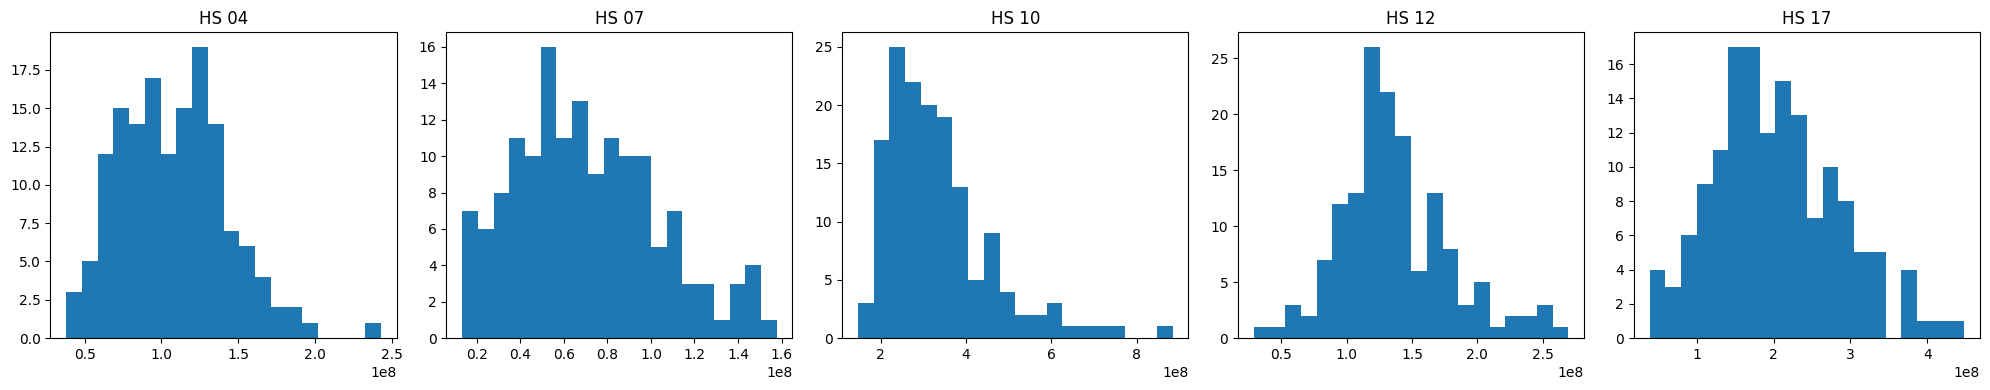

In [15]:
# Visualisasi distribusi dengan histogram
hs_list = sorted(df['Kode_HS'].unique())
fig, axes = plt.subplots(1, len(hs_list), figsize=(20,4))

for ax, hs in zip(axes, hs_list):
    data_hs = df[df['Kode_HS']==hs]['Nilai_USD']
    ax.hist(data_hs, bins=20)
    ax.set_title(f'HS {hs}')

plt.tight_layout()
plt.show()

* Semua komoditas adalah right-skewed dengan tingkat yang berbeda-beda
* HS 10 memiliki skewness yang tinggi yaitu 1.54 jauh di atas komoditas lain, kurtosis 3.27 juga menandakan potensi adanya outlier yang menarik distribusi ke kanan. Oleh karena itu, HS 10 menjadi kandidat kuat untuk log-transform yang dapat membantu menstabilkan distribusi sebelum modeling

### Data Quality Check

In [16]:
# Cek missing value
df.isna().sum()

,0
Periode,0
Kode_HS,0
Nilai_USD,0


In [17]:
# Cek value duplikat
df.duplicated(subset=['Periode','Kode_HS']).sum()

np.int64(0)

In [18]:
# Cek apakah ada gap dalam periode
expected_periods = pd.date_range(start='2014-01-01', end='2026-05-01', freq='MS')
for hs in df['Kode_HS'].unique():
    actual_periods = set(df[df['Kode_HS'] == hs]['Periode'])
    missing = set(expected_periods) - actual_periods
    if missing:
        print(f"HS {hs} — bulan yang hilang: {sorted(missing)}")
    else:
        print(f"HS {hs} — lengkap, tidak ada gap")

HS 04 — lengkap, tidak ada gap
HS 07 — lengkap, tidak ada gap
HS 10 — lengkap, tidak ada gap
HS 12 — lengkap, tidak ada gap
HS 17 — lengkap, tidak ada gap


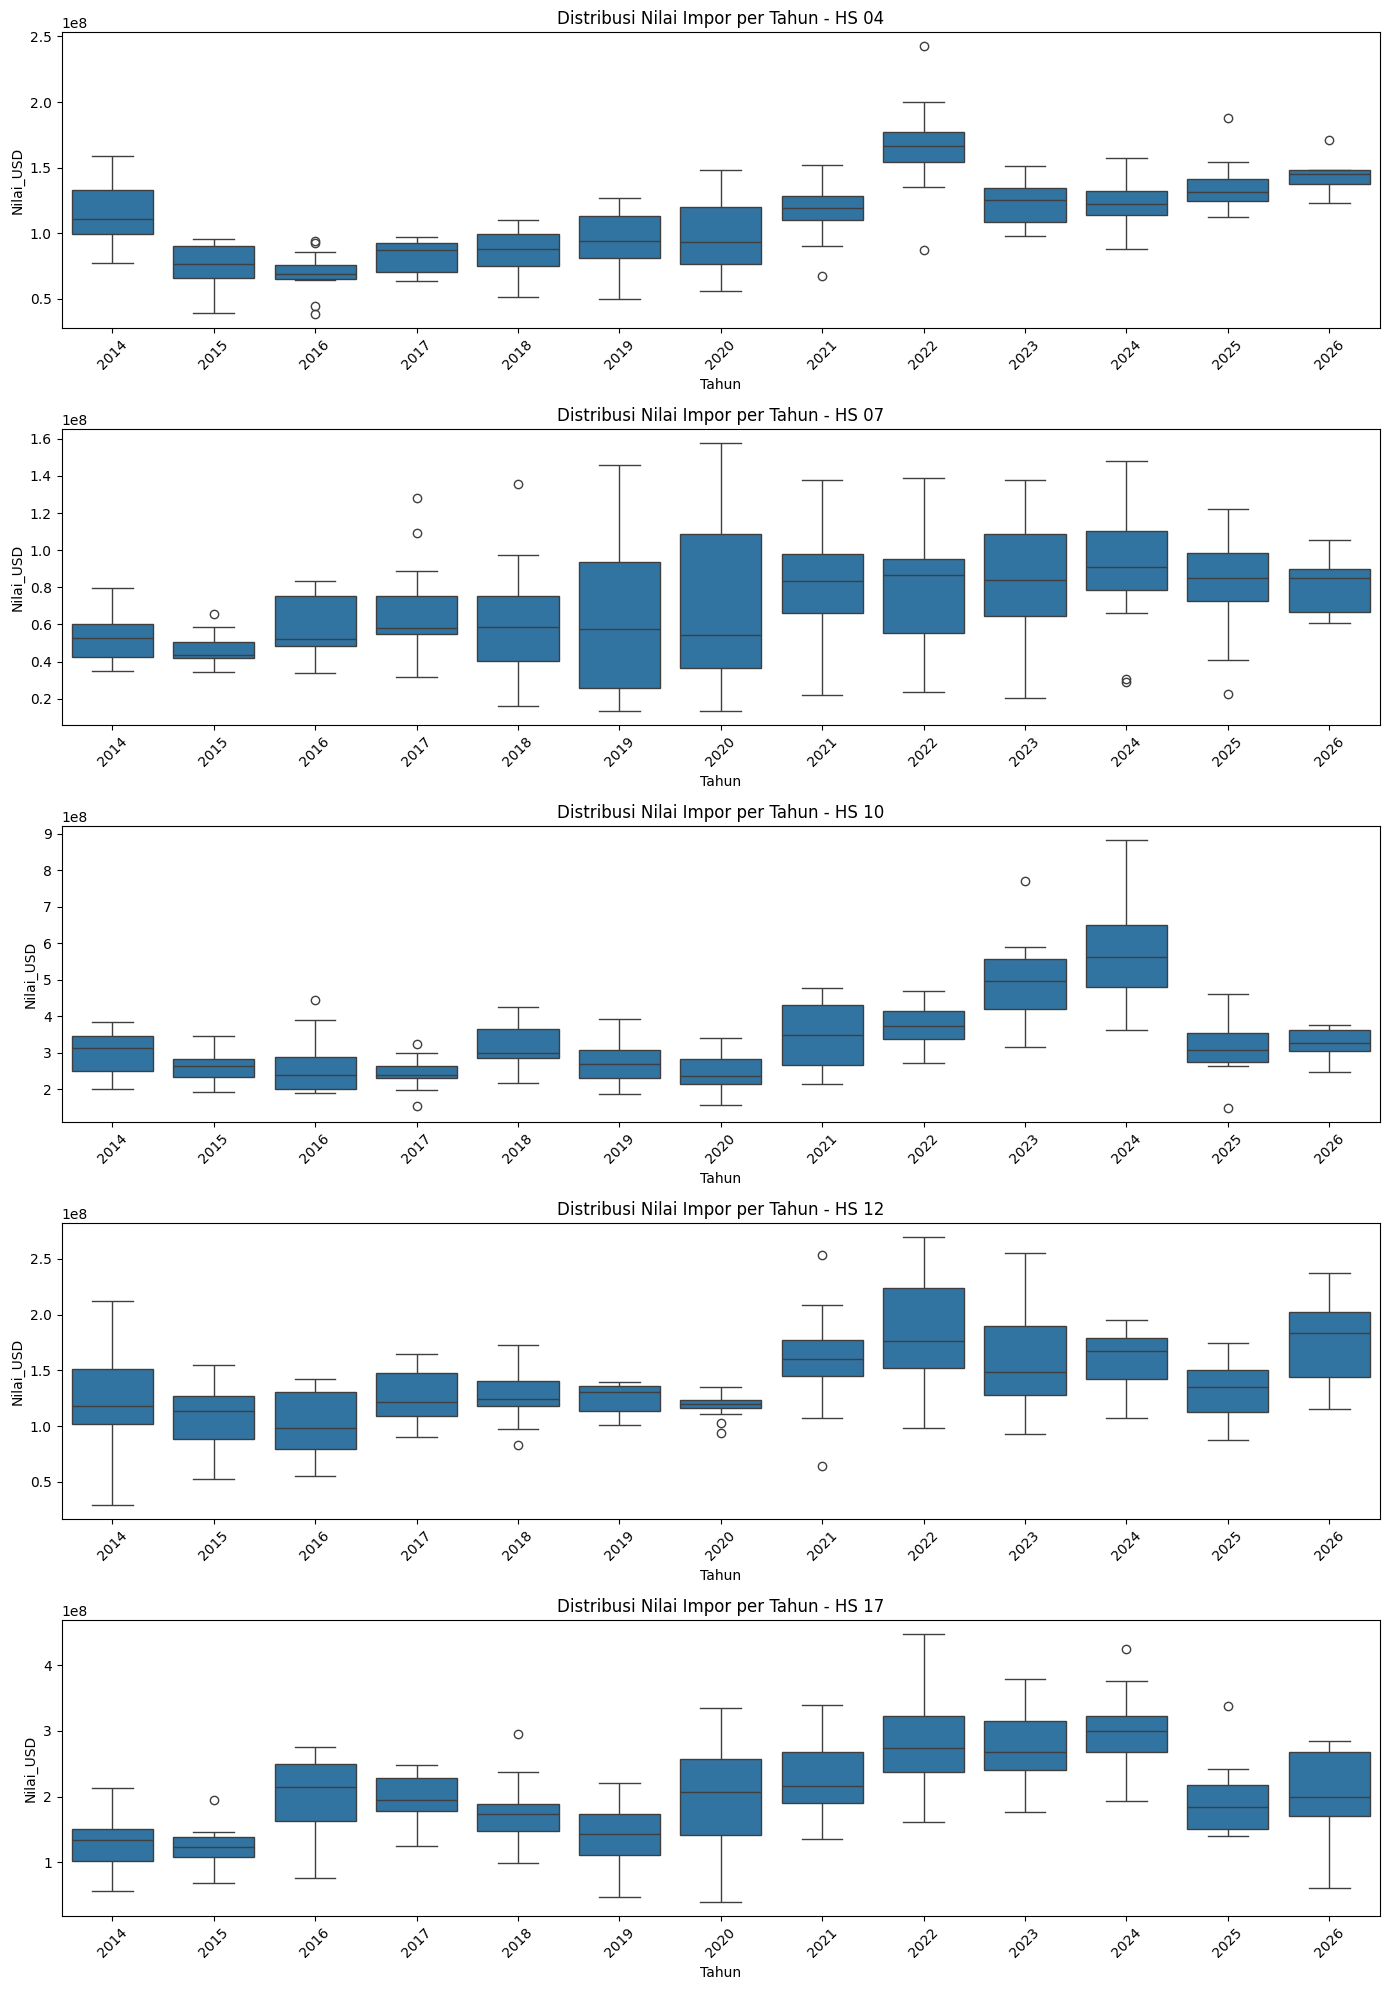

In [19]:
# Cek outlier memakai boxplot
df['Tahun'] = df['Periode'].dt.year
hs_list = df['Kode_HS'].unique()
fig, axes = plt.subplots(len(hs_list), 1, figsize=(14, 4*len(hs_list)))

for ax, hs in zip(axes, hs_list):
    data_hs = df[df['Kode_HS'] == hs]
    sns.boxplot(data=data_hs, x='Tahun', y='Nilai_USD', ax=ax)
    ax.set_title(f'Distribusi Nilai Impor per Tahun - HS {hs}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Exploratory Data Analysis

#### Line Plot Time Series per Komoditas

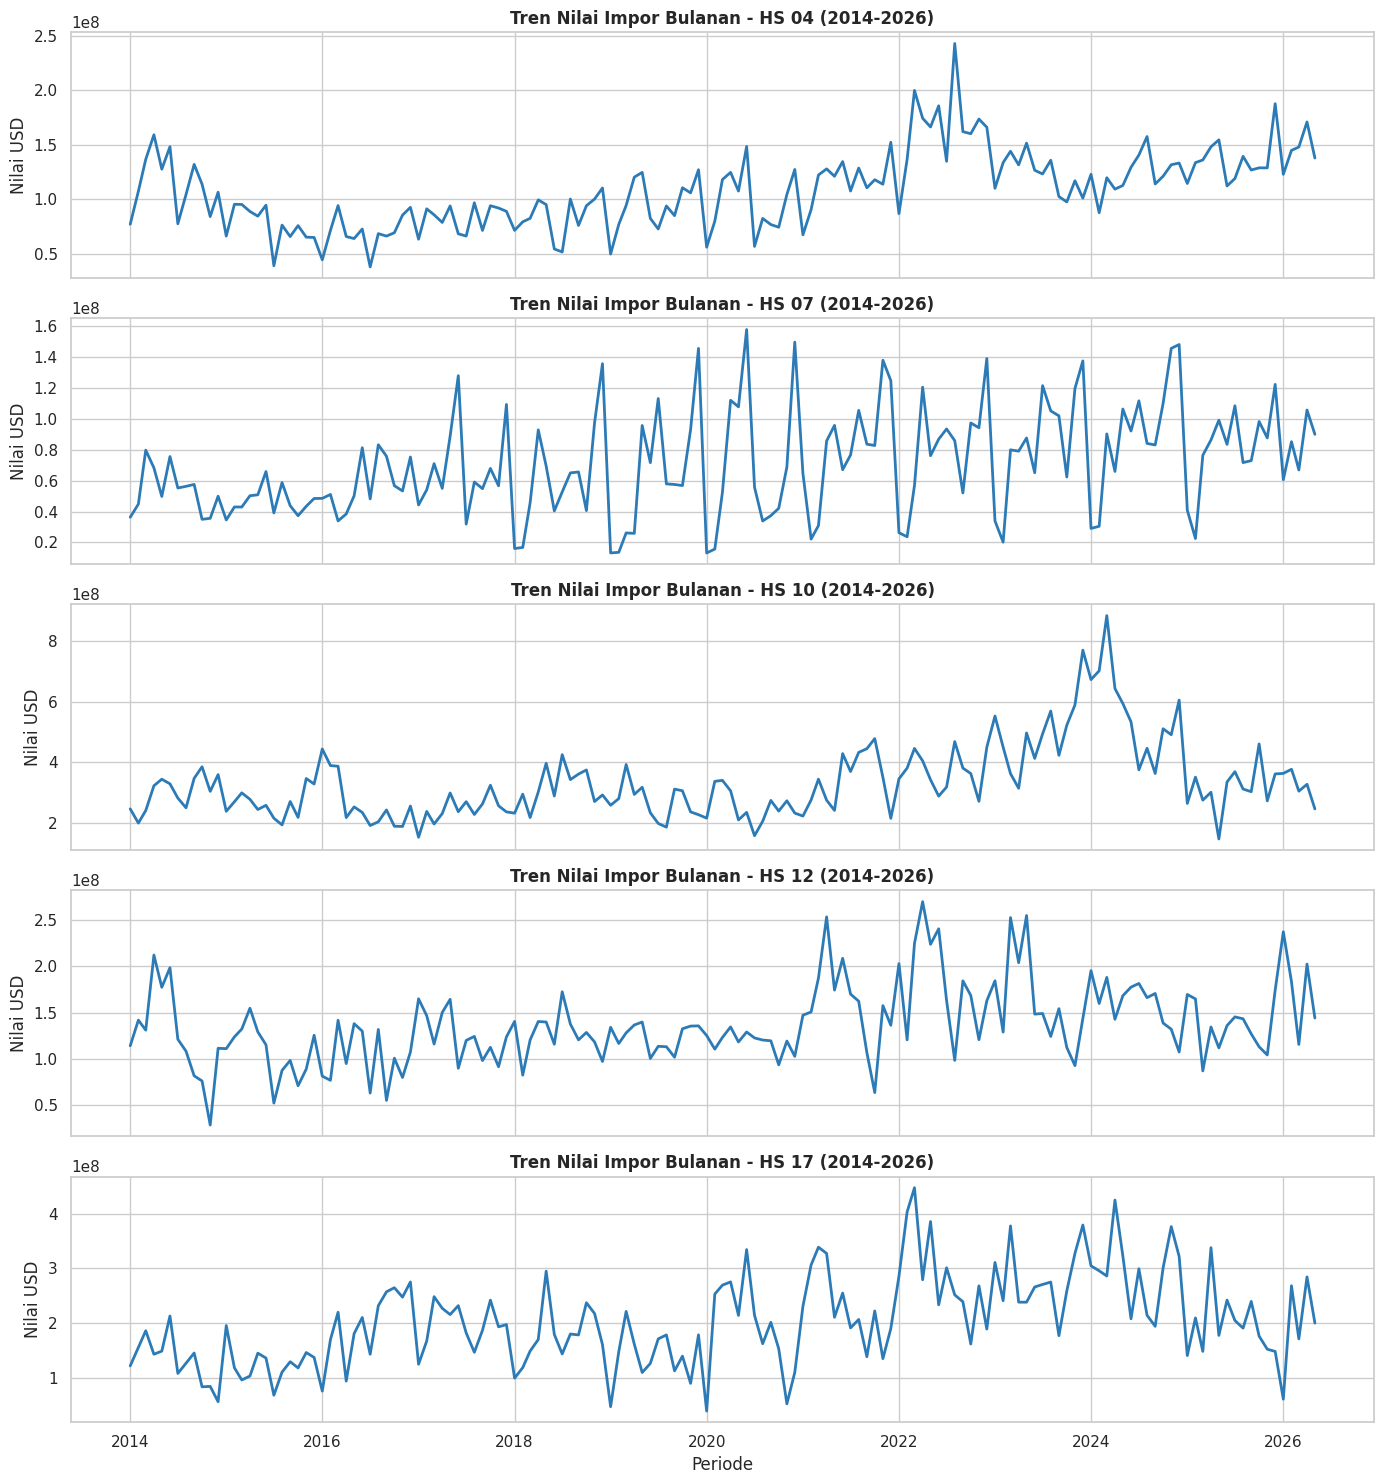

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df.sort_values(by=['Kode_HS', 'Periode'])

sns.set_theme(style="whitegrid")
hs_list = sorted(df['Kode_HS'].unique())

# Individual Subplots
# sharex=True aligns the x-axis timeline perfectly across all plots
fig, axes = plt.subplots(len(hs_list), 1, figsize=(14, 3 * len(hs_list)), sharex=True)

for ax, hs in zip(axes, hs_list):
    data_hs = df[df['Kode_HS'] == hs]

    # Plot the line chart for each specific HS code
    sns.lineplot(data=data_hs, x='Periode', y='Nilai_USD', ax=ax, linewidth=2, color='#2c7bb6')

    # Formatting for professional appearance
    ax.set_title(f'Tren Nilai Impor Bulanan - HS {hs} (2014-2026)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Nilai USD')
    ax.set_xlabel('Periode')

plt.tight_layout()
plt.show()

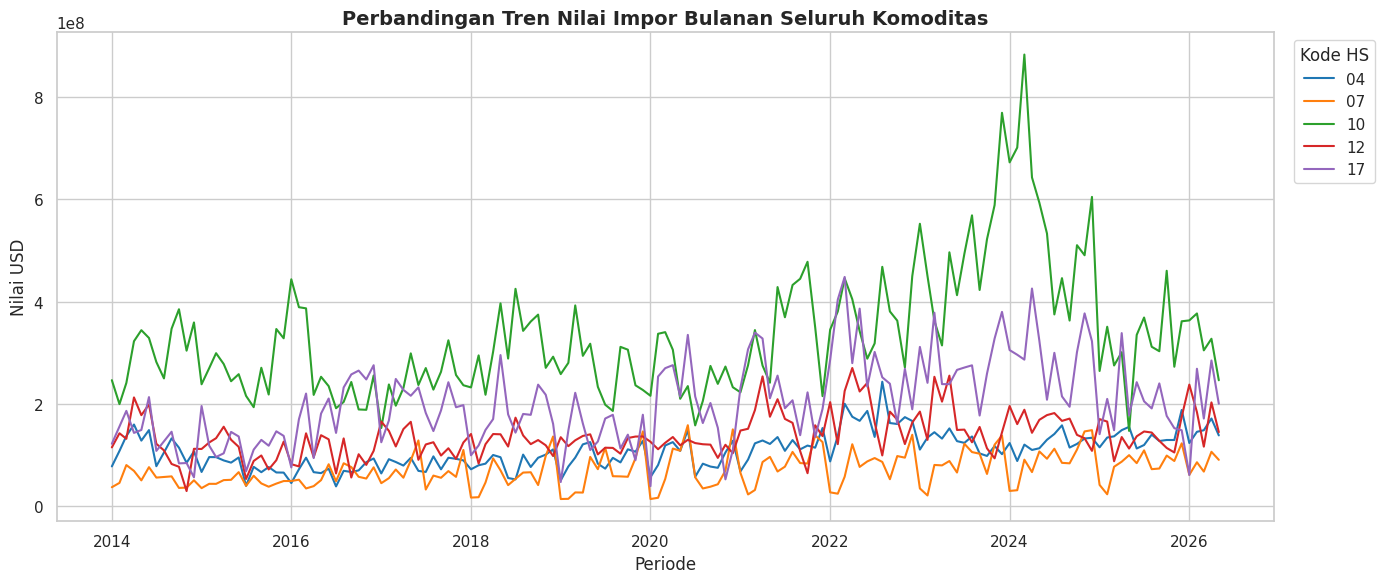

In [21]:
# Combined Overlay Plot
plt.figure(figsize=(14, 6))

# The 'hue' parameter automatically colors the lines by HS code
sns.lineplot(data=df, x='Periode', y='Nilai_USD', hue='Kode_HS', linewidth=1.5, palette='tab10')

plt.title('Perbandingan Tren Nilai Impor Bulanan Seluruh Komoditas', fontsize=14, fontweight='bold')
plt.ylabel('Nilai USD')
plt.xlabel('Periode')

# Place the legend outside the plot so it doesn't cover the data
plt.legend(title='Kode HS', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Dari line plot, dapat diketahui bahwa data nilai impor bersifat non-stasioner karena tidak memiliki mean dan varians yang konstan seiring berjalannya waktu. Model linear klasik membutuhkan differencing untuk menstabilkan data. Line plot ini mengindikasikan adanya pola seasonality dan cyclicality.

#### Growth Rate Year-over-Year (YoY)

In [27]:
# Eksplorasi Growth Rate Year-over-Year (YoY)
# Total nilai impor per tahun per komoditas
yearly = df.groupby(['Kode_HS','Tahun'])['Nilai_USD'].sum().reset_index()

# YoY growth rate per komoditas
yearly['YoY_Growth_%'] = yearly.groupby('Kode_HS')['Nilai_USD'].pct_change() * 100
yearly = yearly[yearly['Tahun'] < 2026]

pd.set_option('display.max_rows', None)
yearly

,Kode_HS,Tahun,Nilai_USD,YoY_Growth_%
0,04,2014,1.374223e+09,NaN
1,04,2015,9.117069e+08,-33.656567
2,04,2016,8.324027e+08,-8.698422
3,04,2017,9.905174e+08,18.994976
4,04,2018,1.014479e+09,2.419119
5,04,2019,1.143428e+09,12.710815
6,04,2020,1.156623e+09,1.154031
7,04,2021,1.394290e+09,20.548316
8,04,2022,1.989220e+09,42.669021
9,04,2023,1.474328e+09,-25.884109


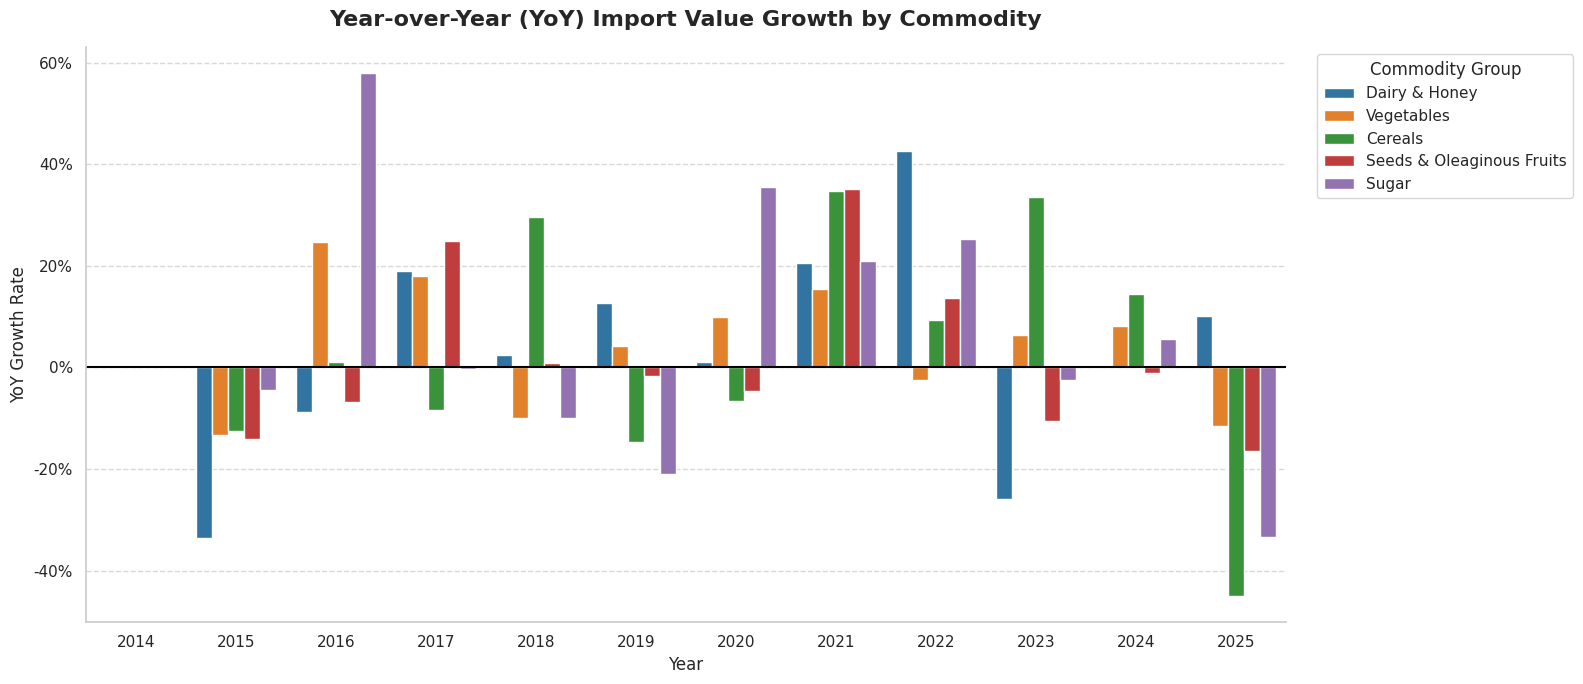

In [28]:
# Visualisasi Growth Rate YoY
hs_mapping = {
    '04': 'Dairy & Honey',
    '07': 'Vegetables',
    '10': 'Cereals',
    '12': 'Seeds & Oleaginous Fruits',
    '17': 'Sugar'
}

yearly['Commodity'] = yearly['Kode_HS'].map(hs_mapping)

plt.figure(figsize=(16, 7))
ax = sns.barplot(
    data=yearly,
    x='Tahun',
    y='YoY_Growth_%',
    hue='Commodity',
    palette='tab10'
)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')
plt.title('Year-over-Year (YoY) Import Value Growth by Commodity', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('YoY Growth Rate', fontsize=12)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}%'))
ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.3)

plt.legend(title='Commodity Group', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine()

plt.tight_layout()
plt.show()

Grafik menunjukkan volatilitas yang tinggi (naik turun cepat dalam rentang luas dalam waktu singkat). Hal ini menunjukkan nilai impor rentan terhadap macroeconomic shocks (peristiwa atau perubahan mendadak yang memengaruhi ekonomi), sehingga model statistik klasik seringkali kesusahan untuk melakukan prediksi.

#### Seasonal Decomposition

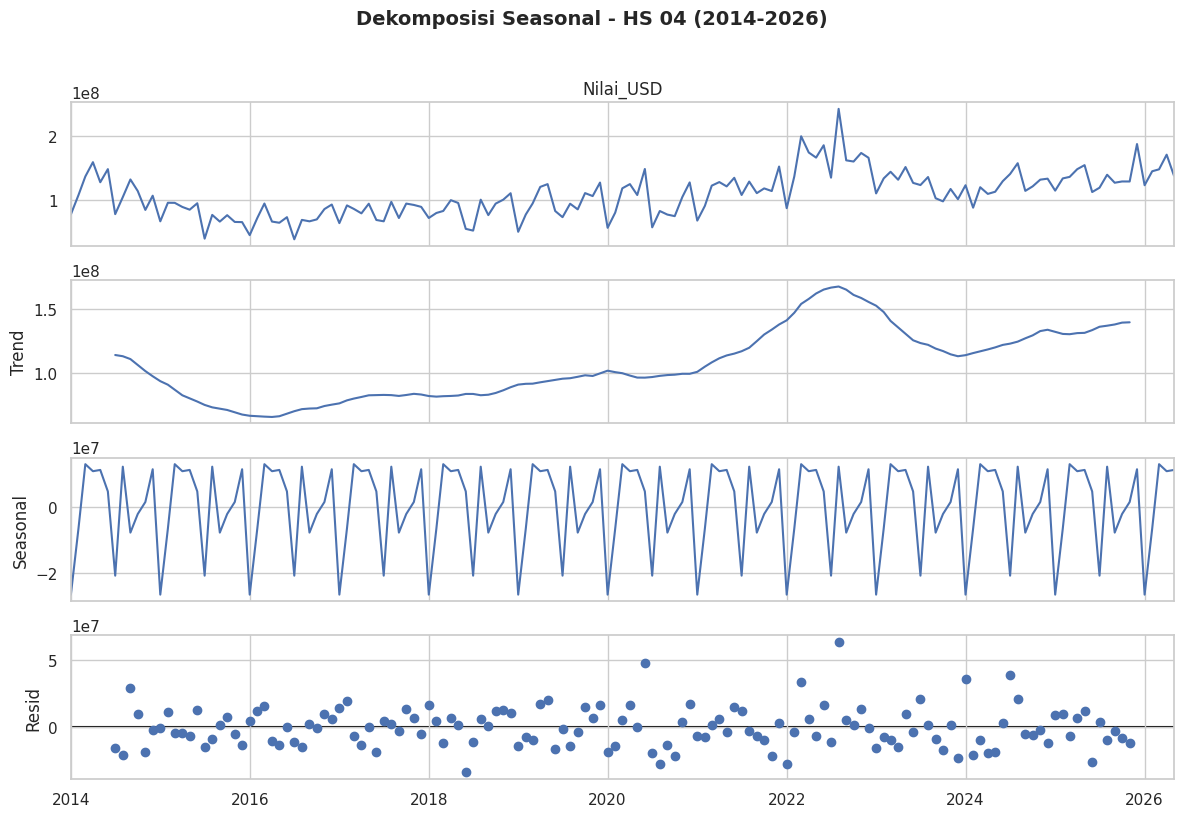

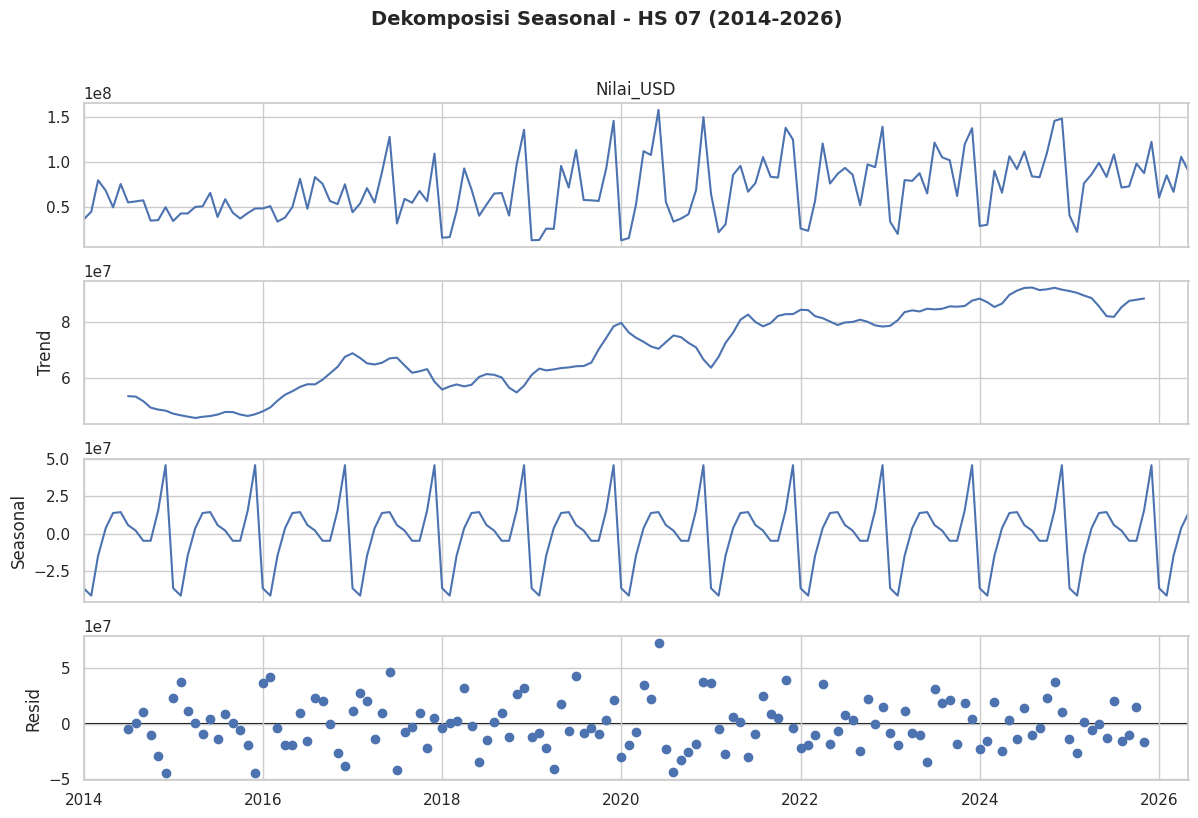

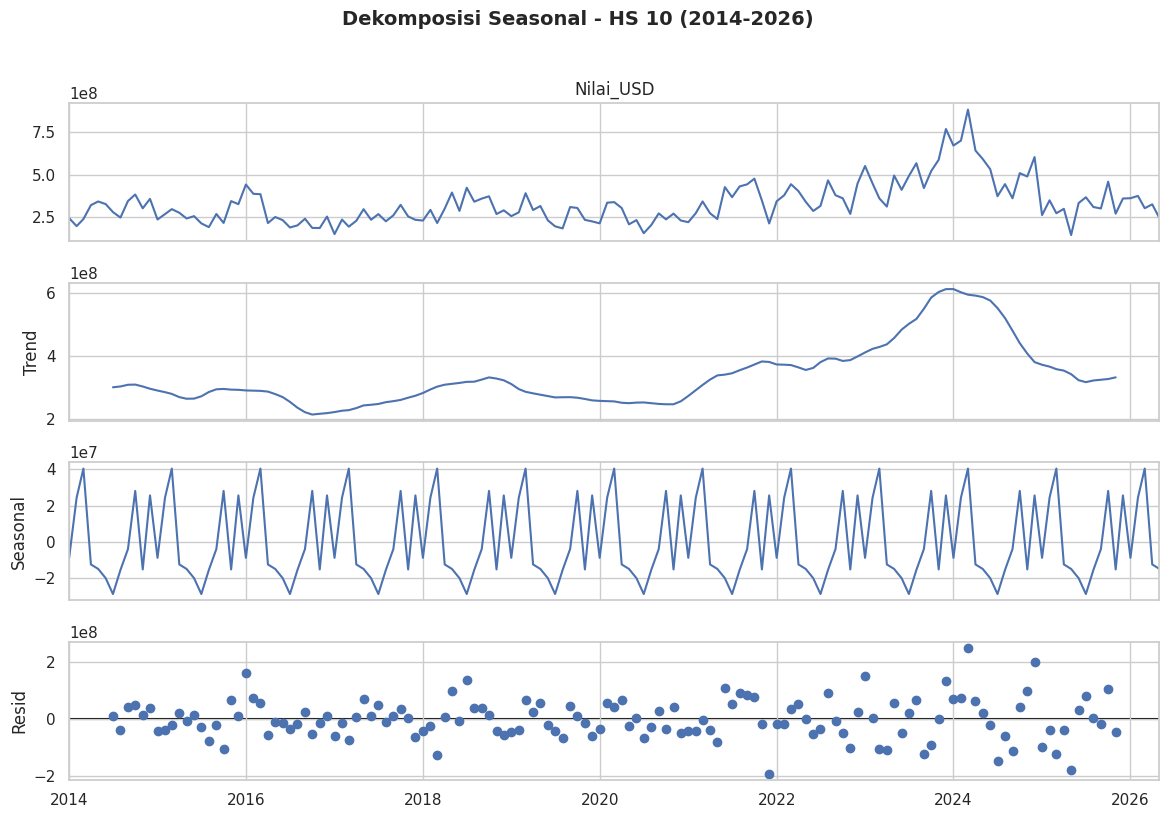

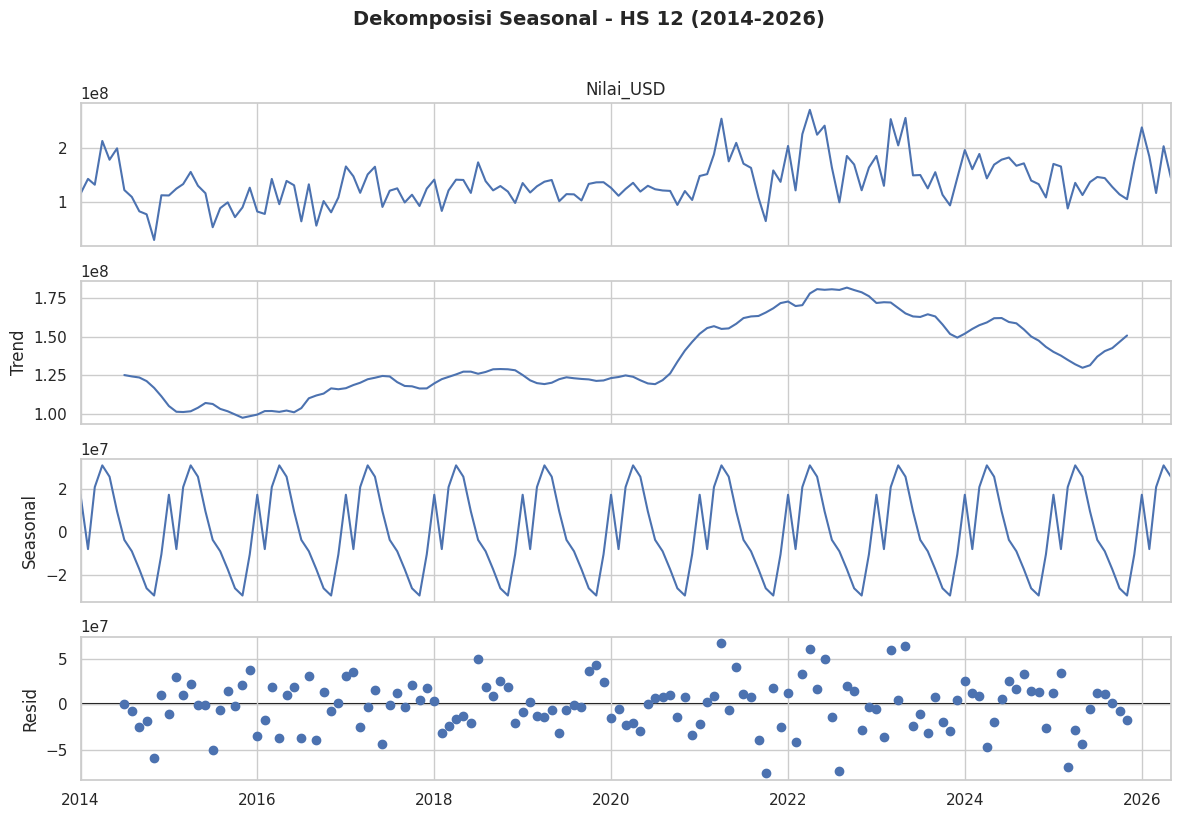

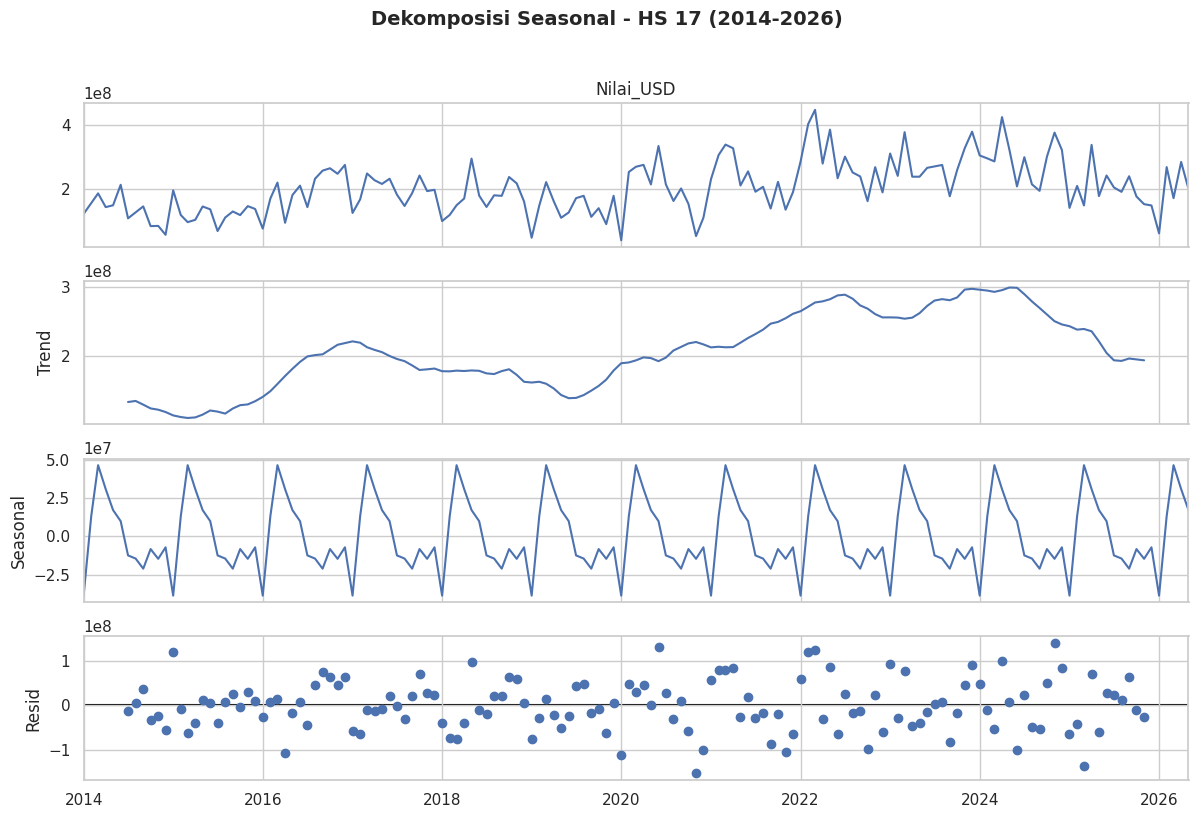

In [23]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

hs_list = sorted(df['Kode_HS'].unique())

for hs in hs_list:
    data_hs = df[df['Kode_HS'] == hs].copy()
    data_hs.set_index('Periode', inplace=True)

    # 3. Explicitly set the frequency to Month Start ('MS') to prevent indexing errors
    data_hs = data_hs.asfreq('MS')

    # 4. Perform the seasonal decomposition
    # We use period=12 because the data is monthly and we expect annual seasonality
    decomposition = seasonal_decompose(data_hs['Nilai_USD'], model='additive', period=12)

    fig = decomposition.plot()
    fig.set_size_inches(12, 8)

    # Add a custom title and adjust spacing
    fig.suptitle(f'Dekomposisi Seasonal - HS {hs} (2014-2026)', fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

Plot ini mengonfirmasi adanya volatilitas tinggi dan non-stationarity pada seluruh bahan baku pangan. Tren menunjukkan bahwa mean berdasarkan waktu tidak konstan yang menunjukkan data ini non-stasioner. Komponen seasonal menunjukkan adanya pola seasonality setiap 12 bulan pada setiap komoditas yang mengonfirmasi penggunaan seasonal autoregressive and moving average parameters pada model SARIMA. Hasil residual analysis juga menunjukkan limitasi metode statistik klasik pada dataset ini karena varians noise yang tidak konstan (heteroskedasticity). Ini menjadi alasan untuk menggunakan machine learning sebagai solusi untuk menangani noise yang kompleks ini.

#### Uji Stasioneritas (ADF & KPSS)

In [24]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Initialize a list to store the formal results for your journal table
adf_results = []
hs_list = sorted(df['Kode_HS'].unique())

for hs in hs_list:
    # Extract the time series for the specific commodity
    data_hs = df[df['Kode_HS'] == hs]['Nilai_USD'].dropna()

    # Step 1: Run ADF on the original raw data (d = 0)
    result_raw = adfuller(data_hs)
    p_val_raw = result_raw[1]

    # Check if the raw data is already stationary (p-value < 0.05)
    if p_val_raw < 0.05:
        d = 0
        final_p_val = p_val_raw
        status = "Stasioner (Level 0)"
    else:
        # Step 2: Apply 1st order differencing (d = 1)
        data_diff1 = data_hs.diff().dropna()
        result_diff1 = adfuller(data_diff1)
        p_val_diff1 = result_diff1[1]

        if p_val_diff1 < 0.05:
            d = 1
            final_p_val = p_val_diff1
            status = "Stasioner (Differencing 1)"
        else:
            # Step 3: Apply 2nd order differencing (d = 2)
            # It is extremely rare for economic data to need more than d=2
            data_diff2 = data_diff1.diff().dropna()
            result_diff2 = adfuller(data_diff2)
            p_val_diff2 = result_diff2[1]

            d = 2
            final_p_val = p_val_diff2
            status = "Stasioner (Differencing 2)"

    # Save the results for this commodity
    adf_results.append({
        'Kode HS': hs,
        'P-Value (Data Asli)': f"{p_val_raw:.4f}",
        'Ordo Differencing (d)': d,
        'P-Value (Final)': f"{final_p_val:.4f}",
        'Kesimpulan': status
    })

# Convert the results into a clean Pandas DataFrame
df_adf_summary = pd.DataFrame(adf_results)
print(df_adf_summary.to_string(index=False))

Kode HS P-Value (Data Asli)  Ordo Differencing (d) P-Value (Final)                 Kesimpulan
     04              0.5347                      1          0.0207 Stasioner (Differencing 1)
     07              0.7498                      1          0.0000 Stasioner (Differencing 1)
     10              0.0124                      0          0.0124        Stasioner (Level 0)
     12              0.6137                      1          0.0000 Stasioner (Differencing 1)
     17              0.3214                      1          0.0023 Stasioner (Differencing 1)


Dari hasil uji stasioner ini, ditemukan bahwa 4 komoditas memiliki nilai probabilitas yang jauh di atas batas yang bersifat non-stasioner sehingga membutuhkan differencing tingkat pertama untuk menjadi stasioner. Sedangkan, untuk HS 10, walaupun volatilitasnya tinggi, namun HS 10 memiliki kecenderungan untuk kembali ke nilai rata-rata dalam jangka panjang, sehingga untuk pemodelan SARIMA, HS 10 akan menggunakan parameter d=0.

Hasil pengujian ini sekaligus memberikan justifikasi teoretis yang kuat terhadap penggunaan algoritma machine learning seperti XGBoost sebagai model pembanding. Model berbasis tree seperti XGBoost memiliki keunggulan karena tidak terikat pada asumsi stasioneritas data. Algoritma ini dapat secara langsung memproses data deret waktu yang sangat fluktuatif, menjadikannya solusi yang jauh lebih efisien dan tangguh dalam menghadapi data ekonomi dunia nyata yang kompleks.

#### ACF & PACF Plot

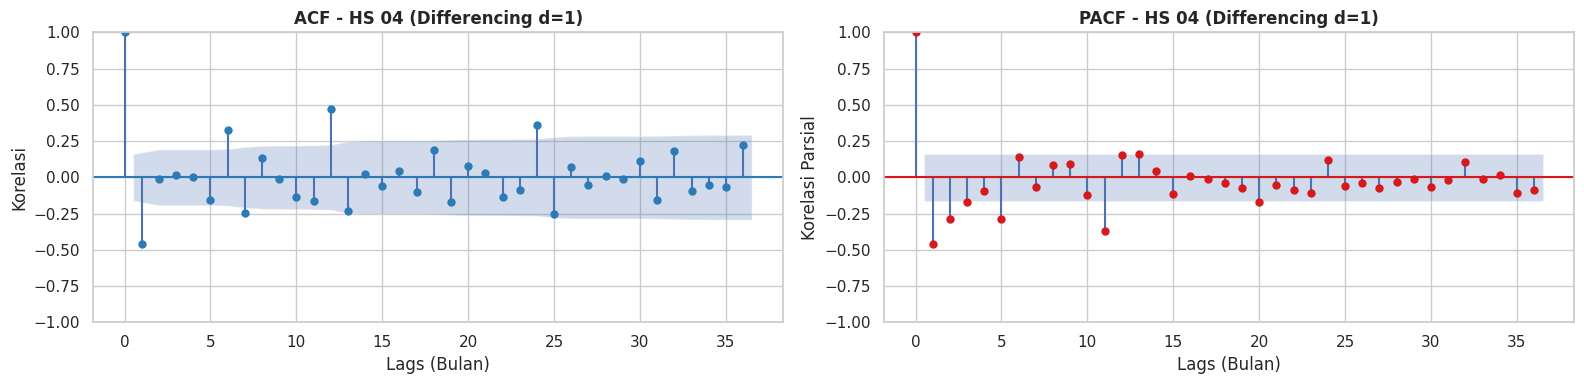

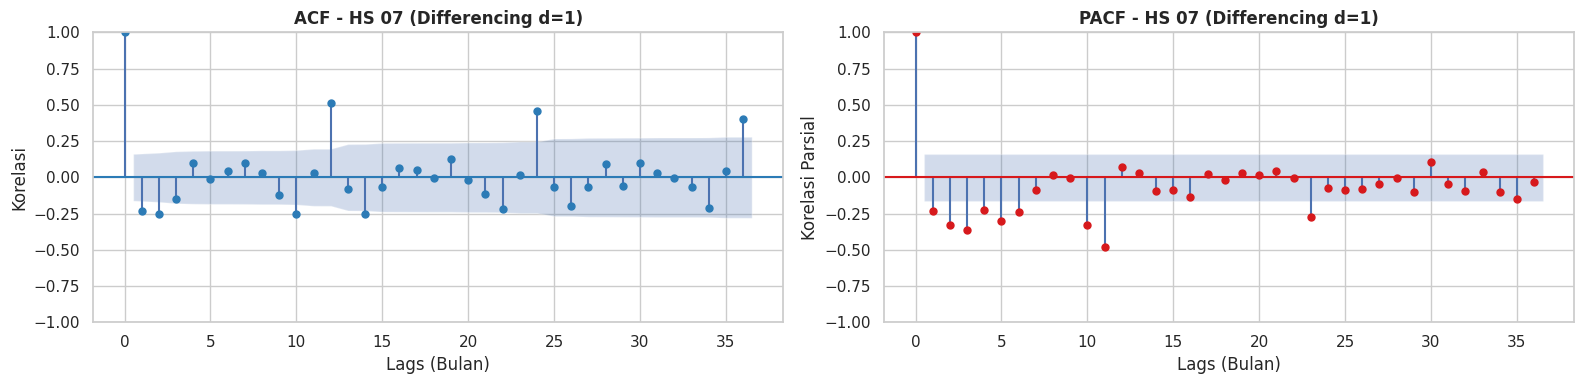

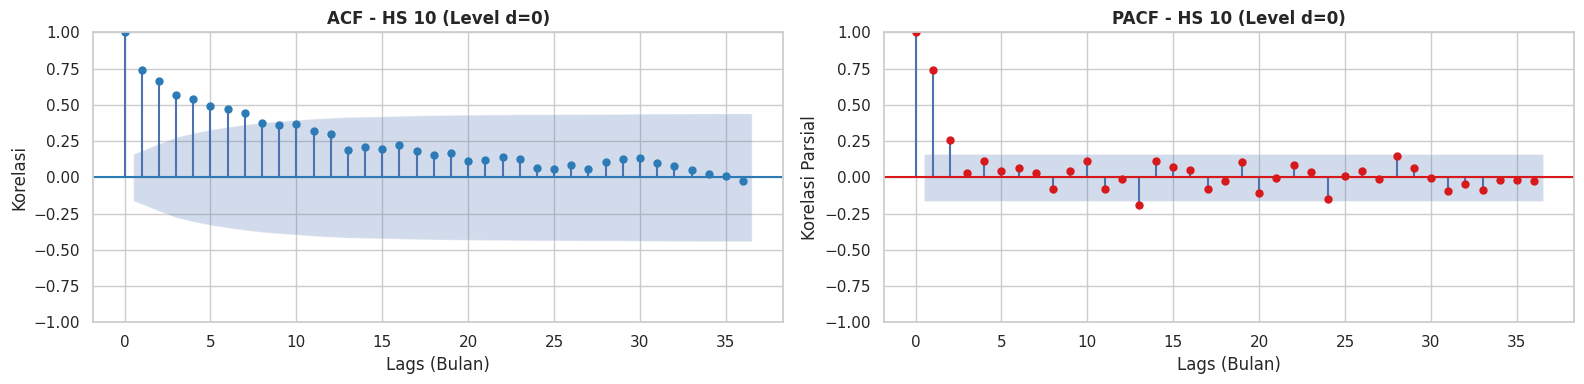

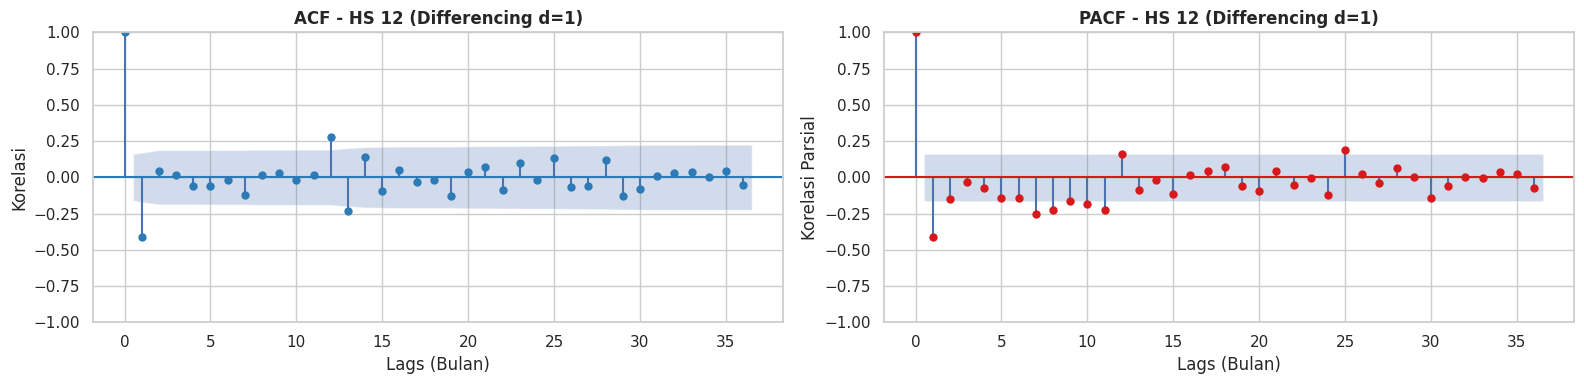

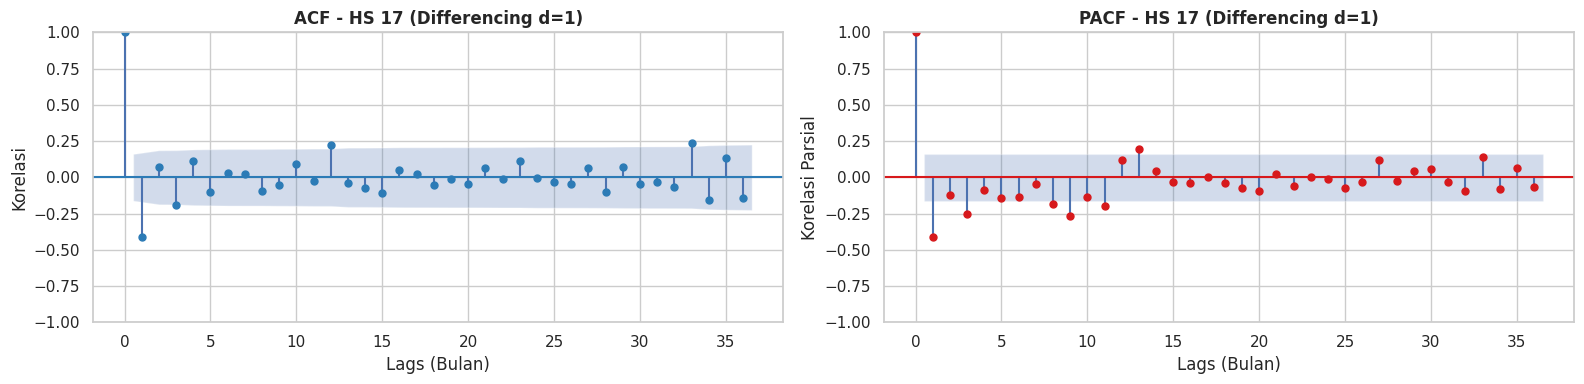

In [25]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Define the differencing order (d) based on your ADF test results
d_orders = {'04': 1, '07': 1, '10': 0, '12': 1, '17': 1}
hs_list = sorted(df['Kode_HS'].unique())

for hs in hs_list:
    # Extract the time series for the specific commodity
    data_hs = df[df['Kode_HS'] == hs].set_index('Periode')['Nilai_USD']

    # Apply the correct differencing dynamically
    d = d_orders[hs]
    if d == 1:
        data_stationary = data_hs.diff().dropna()
        title_suffix = "(Differencing d=1)"
    else:
        data_stationary = data_hs.dropna()
        title_suffix = "(Level d=0)"

    # Create subplots: 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Generate ACF Plot (determines 'q' and 'Q')
    # lags=36 allows us to see 3 full years of seasonality (12, 24, 36)
    plot_acf(data_stationary, lags=36, ax=axes[0], color='#2c7bb6')
    axes[0].set_title(f'ACF - HS {hs} {title_suffix}', fontweight='bold')
    axes[0].set_xlabel('Lags (Bulan)')
    axes[0].set_ylabel('Korelasi')

    # Generate PACF Plot (determines 'p' and 'P')
    plot_pacf(data_stationary, lags=36, ax=axes[1], color='#d7191c', method='ywm')
    axes[1].set_title(f'PACF - HS {hs} {title_suffix}', fontweight='bold')
    axes[1].set_xlabel('Lags (Bulan)')
    axes[1].set_ylabel('Korelasi Parsial')

    plt.tight_layout()
    plt.show()

Analisis ACF dan PACF dilakukan pada data yang telah stasioner untuk mengidentifikasi parameter Autoregressive ($p$) dan Moving Average ($q$) pada model SARIMA. Dari plot tersebut, komoditas Serealia (HS 10) mengindikasikan karakteristik model Autoregressive murni, yakni AR(1).

Sebaliknya, pada komoditas lain yang telah melalui proses differencing tingkat pertama ($d=1$) seperti Susu (HS 04) dan Sayuran (HS 07), terlihat adanya lonjakan negatif yang signifikan pada lag awal di kedua plot, yang mengisyaratkan perlunya kombinasi parameter orde rendah untuk $p$ dan $q$.

Selain komponen non-musiman, plot ACF dan PACF juga memvalidasi keberadaan siklus musiman yang sebelumnya terdeteksi pada dekomposisi pada kelipatan 12 bulan (lag 12 dan lag 24). Fenomena ini memberikan konfirmasi untuk menetapkan parameter frekuensi musiman ($m=12$) serta memasukkan komponen Seasonal Autoregressive ($P$) dan Seasonal Moving Average ($Q$) ke dalam konfigurasi dasar SARIMA.

## Data Preparation 2

### Handling Skewness & Kurtosis

In [26]:
# Cek log-transform ke 5 komoditas
df['log_Nilai_USD'] = np.log(df['Nilai_USD'])

skew_kurt_log = df.groupby('Kode_HS')['log_Nilai_USD'].agg(
    skewness=lambda x: x.skew(),
    kurtosis=lambda x: x.kurt()
).reset_index()

skew_kurt_log

,Kode_HS,skewness,kurtosis
0,04,-0.393390,0.108935
1,07,-0.731760,0.354812
2,10,0.456097,0.181730
3,12,-0.764836,2.832682
4,17,-0.821141,1.040098


HS 10 dan HS 04 membaik dari sebelumnya, sedangkan komoditas yang lain memburuk,sehingga log transform hanya akan diterapkan untuk HS 10 dan HS 04

In [27]:
df.head()

,Periode,Kode_HS,Nilai_USD,Tahun,log_Nilai_USD
0,2014-01-01,04,77115100.0,2014,18.160810
1,2014-02-01,04,107389161.0,2014,18.491970
2,2014-03-01,04,136648208.0,2014,18.732920
3,2014-04-01,04,159130719.0,2014,18.885237
4,2014-05-01,04,127602341.0,2014,18.664429


### Train-Test Split

In [28]:
# Memastikan kolom Periode berformat datetime
df['Periode'] = pd.to_datetime(df['Periode'])

# Melakukan sequential split berdasarkan tanggal
train_df = df[df['Periode'] <= '2024-12-01'].copy()
test_df = df[df['Periode'] > '2024-12-01'].copy()

# Verifikasi total ukuran dataset
print("=== Ringkasan Split Dataset ===")
print(f"Total baris Train : {train_df.shape[0]}")
print(f"Total baris Test  : {test_df.shape[0]}\n")

# Verifikasi rentang waktu
print(f"Rentang Waktu Train : {train_df['Periode'].min().strftime('%Y-%m')} hingga {train_df['Periode'].max().strftime('%Y-%m')}")
print(f"Rentang Waktu Test  : {test_df['Periode'].min().strftime('%Y-%m')} hingga {test_df['Periode'].max().strftime('%Y-%m')}\n")

# Verifikasi jumlah baris per komoditas untuk memastikan tidak ada data yang terlewat
print("=== Detail per Komoditas ===")
for hs in sorted(df['Kode_HS'].unique()):
    train_hs_count = train_df[train_df['Kode_HS'] == hs].shape[0]
    test_hs_count = test_df[test_df['Kode_HS'] == hs].shape[0]
    print(f"HS {hs} -> Train: {train_hs_count} bulan | Test: {test_hs_count} bulan")

=== Ringkasan Split Dataset ===
Total baris Train : 660
Total baris Test  : 85

Rentang Waktu Train : 2014-01 hingga 2024-12
Rentang Waktu Test  : 2025-01 hingga 2026-05

=== Detail per Komoditas ===
HS 04 -> Train: 132 bulan | Test: 17 bulan
HS 07 -> Train: 132 bulan | Test: 17 bulan
HS 10 -> Train: 132 bulan | Test: 17 bulan
HS 12 -> Train: 132 bulan | Test: 17 bulan
HS 17 -> Train: 132 bulan | Test: 17 bulan


## Modeling

In [30]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
!pip install pmdarima
import pmdarima as pm
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

warnings.filterwarnings("ignore")

def create_xgb_features(data):
    df_feat = data.copy()
    df_feat['Month'] = df_feat['Periode'].dt.month
    df_feat['Lag_1'] = df_feat['log_Nilai_USD'].shift(1)
    df_feat['Lag_2'] = df_feat['log_Nilai_USD'].shift(2)
    df_feat['Lag_12'] = df_feat['log_Nilai_USD'].shift(12)
    return df_feat.dropna()

# Initialize global variables to store results across cells
hs_list = sorted(df['Kode_HS'].unique())
d_orders = {'04': 1, '07': 1, '10': 0, '12': 1, '17': 1}
grand_metrics = {hs: {} for hs in hs_list}

print("Setup Complete. Siap melatih model.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.9 MB/s eta 0:00:00
Setup Complete. Siap melatih model.


In [31]:
print("=== 1. Training SARIMA (Baseline) ===")
for hs in hs_list:
    data_hs = df[df['Kode_HS'] == hs].sort_values('Periode').reset_index(drop=True)
    train_df = data_hs[data_hs['Periode'] <= '2024-12-01']
    test_df  = data_hs[data_hs['Periode'] > '2024-12-01']

    y_train = train_df['log_Nilai_USD'].values
    y_test_real = np.exp(test_df['log_Nilai_USD'].values)

    # Train
    sarima_base = SARIMAX(y_train, order=(1, d_orders[hs], 1), seasonal_order=(1, 0, 1, 12))
    sarima_base_fit = sarima_base.fit(disp=False)

    # Forecast & Inverse Transform
    pred_log = sarima_base_fit.forecast(steps=len(test_df))
    pred_real = np.exp(pred_log)

    # Evaluate
    mape = mean_absolute_percentage_error(y_test_real, pred_real)
    grand_metrics[hs]['SARIMA_Base'] = round(mape * 100, 2)
    print(f"HS {hs} Selesai.")

=== 1. Training SARIMA (Baseline) ===
HS 04 Selesai.
HS 07 Selesai.
HS 10 Selesai.
HS 12 Selesai.
HS 17 Selesai.


In [32]:
print("=== 2. Training Auto-ARIMA (Tuned) ===")
for hs in hs_list:
    data_hs = df[df['Kode_HS'] == hs].sort_values('Periode').reset_index(drop=True)
    train_df = data_hs[data_hs['Periode'] <= '2024-12-01']
    test_df  = data_hs[data_hs['Periode'] > '2024-12-01']

    y_train = train_df['log_Nilai_USD'].values
    y_test_real = np.exp(test_df['log_Nilai_USD'].values)

    # Train
    auto_model = pm.auto_arima(y_train, d=d_orders[hs], seasonal=True, m=12,
                               trace=False, error_action='ignore', suppress_warnings=True,
                               stepwise=True)

    # Forecast & Inverse Transform
    pred_log = auto_model.predict(n_periods=len(test_df))
    pred_real = np.exp(pred_log)

    # Evaluate
    mape = mean_absolute_percentage_error(y_test_real, pred_real)
    grand_metrics[hs]['SARIMA_Tuned'] = round(mape * 100, 2)
    print(f"HS {hs} Selesai.")

=== 2. Training Auto-ARIMA (Tuned) ===
HS 04 Selesai.
HS 07 Selesai.
HS 10 Selesai.
HS 12 Selesai.
HS 17 Selesai.


In [33]:
print("=== 3. Training XGBoost (Baseline) ===")
for hs in hs_list:
    data_hs = df[df['Kode_HS'] == hs].sort_values('Periode').reset_index(drop=True)
    xgb_data = create_xgb_features(data_hs)

    xgb_train = xgb_data[xgb_data['Periode'] <= '2024-12-01']
    xgb_test  = xgb_data[xgb_data['Periode'] > '2024-12-01']

    # Apply your conditional logic safely
    is_logged_xgb = hs in ['04', '10']

    y_train_xgb = xgb_train['log_Nilai_USD'] if is_logged_xgb else xgb_train['Nilai_USD']
    y_test_xgb_actual = np.exp(xgb_test['log_Nilai_USD'].values) # Always compare against real USD

    X_train_xgb = xgb_train.drop(columns=['Periode', 'Kode_HS', 'Nilai_USD', 'Tahun', 'log_Nilai_USD'])
    X_test_xgb = xgb_test.drop(columns=['Periode', 'Kode_HS', 'Nilai_USD', 'Tahun', 'log_Nilai_USD'])

    # Train
    xgb_base = XGBRegressor(random_state=42, objective='reg:squarederror')
    xgb_base.fit(X_train_xgb, y_train_xgb)

    # Forecast
    pred_raw = xgb_base.predict(X_test_xgb)

    # BUG FIX: Only apply np.exp() if the data was actually log-transformed
    pred_real = np.exp(pred_raw) if is_logged_xgb else pred_raw

    # Evaluate
    mape = mean_absolute_percentage_error(y_test_xgb_actual, pred_real)
    grand_metrics[hs]['XGB_Base'] = round(mape * 100, 2)
    print(f"HS {hs} Selesai.")

=== 3. Training XGBoost (Baseline) ===
HS 04 Selesai.
HS 07 Selesai.
HS 10 Selesai.
HS 12 Selesai.
HS 17 Selesai.


In [34]:
print("=== 4. Training XGBoost (Tuned) ===")
tscv = TimeSeriesSplit(n_splits=3)
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

for hs in hs_list:
    data_hs = df[df['Kode_HS'] == hs].sort_values('Periode').reset_index(drop=True)
    xgb_data = create_xgb_features(data_hs)

    xgb_train = xgb_data[xgb_data['Periode'] <= '2024-12-01']
    xgb_test  = xgb_data[xgb_data['Periode'] > '2024-12-01']

    is_logged_xgb = hs in ['04', '10']
    y_train_xgb = xgb_train['log_Nilai_USD'] if is_logged_xgb else xgb_train['Nilai_USD']
    y_test_xgb_actual = np.exp(xgb_test['log_Nilai_USD'].values)

    X_train_xgb = xgb_train.drop(columns=['Periode', 'Kode_HS', 'Nilai_USD', 'Tahun', 'log_Nilai_USD'])
    X_test_xgb = xgb_test.drop(columns=['Periode', 'Kode_HS', 'Nilai_USD', 'Tahun', 'log_Nilai_USD'])

    # Train & Tune
    xgb_tuned = GridSearchCV(estimator=XGBRegressor(random_state=42, objective='reg:squarederror'),
                             param_grid=param_grid,
                             cv=tscv,
                             scoring='neg_mean_absolute_percentage_error',
                             n_jobs=-1)

    xgb_tuned.fit(X_train_xgb, y_train_xgb)

    # Forecast
    pred_raw = xgb_tuned.predict(X_test_xgb)

    # BUG FIX: Only apply np.exp() if the data was actually log-transformed
    pred_real = np.exp(pred_raw) if is_logged_xgb else pred_raw

    # Evaluate
    mape = mean_absolute_percentage_error(y_test_xgb_actual, pred_real)
    grand_metrics[hs]['XGB_Tuned'] = round(mape * 100, 2)
    print(f"HS {hs} Selesai.")

# ==========================================
# FINAL OUTPUT GENERATION
# ==========================================
final_df = pd.DataFrame.from_dict(grand_metrics, orient='index').reset_index()
final_df.rename(columns={'index': 'Kode_HS'}, inplace=True)

print("\n=== Tabel Perbandingan Evaluasi Akhir (MAPE %) ===")
print(final_df.to_string(index=False))

=== 4. Training XGBoost (Tuned) ===
HS 04 Selesai.
HS 07 Selesai.
HS 10 Selesai.
HS 12 Selesai.
HS 17 Selesai.

=== Tabel Perbandingan Evaluasi Akhir (MAPE %) ===
Kode_HS  SARIMA_Base  SARIMA_Tuned  XGB_Base  XGB_Tuned
     04        12.19         14.63     19.03      11.97
     07        17.88         19.19     21.23      20.66
     10        80.21         39.60     35.70      34.90
     12        27.93         29.87     29.19      19.96
     17        71.44         71.53     41.26      42.05


In [35]:
print("=== 3. Training XGBoost (Baseline) ===")

# Fungsi ini mengembalikan logika persis seperti eksperimen asli Anda
def get_xgb_df(df, hs, is_logged):
    subset = df[df['Kode_HS'] == hs].sort_values('Periode')
    subset = subset.set_index('Periode').asfreq('MS')

    y = np.log(subset['Nilai_USD']) if is_logged else subset['Nilai_USD']

    df_ml = pd.DataFrame({'y': y})
    df_ml['lag_1'] = df_ml['y'].shift(1)
    df_ml['lag_2'] = df_ml['y'].shift(2)
    df_ml['lag_12'] = df_ml['y'].shift(12)
    df_ml['bulan'] = df_ml.index.month
    return df_ml.dropna()

train_end_date = '2024-12-01'

for hs in hs_list:
    is_logged = hs in ['04', '10']
    df_ml = get_xgb_df(df, hs, is_logged)

    train_df = df_ml[:train_end_date]
    test_df = df_ml[pd.to_datetime(train_end_date) + pd.DateOffset(months=1):]

    X_train, y_train = train_df.drop(columns=['y']), train_df['y']
    X_test, y_test = test_df.drop(columns=['y']), test_df['y']

    # Train
    xgb_default = XGBRegressor(random_state=42)
    xgb_default.fit(X_train, y_train)

    # Forecast
    pred_default = xgb_default.predict(X_test)

    # Inverse transform if necessary
    test_actual = np.exp(y_test) if is_logged else y_test
    forecast_actual = np.exp(pred_default) if is_logged else pred_default

    # Evaluate
    mape = mean_absolute_percentage_error(test_actual, forecast_actual)
    grand_metrics[hs]['XGB_Base'] = round(mape * 100, 2)
    print(f"HS {hs} Selesai.")

=== 3. Training XGBoost (Baseline) ===
HS 04 Selesai.
HS 07 Selesai.
HS 10 Selesai.
HS 12 Selesai.
HS 17 Selesai.


In [36]:
print("=== 4. Training XGBoost (Tuned) ===")
tscv = TimeSeriesSplit(n_splits=3)

# Mengembalikan parameter grid persis seperti eksperimen asli Anda
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

train_end_date = '2024-12-01'

for hs in hs_list:
    is_logged = hs in ['04', '10']
    df_ml = get_xgb_df(df, hs, is_logged)

    train_df = df_ml[:train_end_date]
    test_df = df_ml[pd.to_datetime(train_end_date) + pd.DateOffset(months=1):]

    X_train, y_train = train_df.drop(columns=['y']), train_df['y']
    X_test, y_test = test_df.drop(columns=['y']), test_df['y']

    # Train & Tune
    xgb_base = XGBRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, cv=tscv,
                               scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Forecast
    pred_tuned = grid_search.best_estimator_.predict(X_test)

    # Inverse transform if necessary
    test_actual = np.exp(y_test) if is_logged else y_test
    forecast_actual = np.exp(pred_tuned) if is_logged else pred_tuned

    # Evaluate
    mape = mean_absolute_percentage_error(test_actual, forecast_actual)
    grand_metrics[hs]['XGB_Tuned'] = round(mape * 100, 2)
    print(f"HS {hs} Selesai.")

# ==========================================
# FINAL OUTPUT GENERATION
# ==========================================
final_df = pd.DataFrame.from_dict(grand_metrics, orient='index').reset_index()
final_df.rename(columns={'index': 'Kode_HS'}, inplace=True)

print("\n=== Tabel Perbandingan Evaluasi Akhir (MAPE %) ===")
print(final_df.to_string(index=False))

=== 4. Training XGBoost (Tuned) ===
HS 04 Selesai.
HS 07 Selesai.
HS 10 Selesai.
HS 12 Selesai.
HS 17 Selesai.

=== Tabel Perbandingan Evaluasi Akhir (MAPE %) ===
Kode_HS  SARIMA_Base  SARIMA_Tuned  XGB_Base  XGB_Tuned
     04        12.19         14.63     18.91      10.80
     07        17.88         19.19     22.36      21.37
     10        80.21         39.60     36.60      29.03
     12        27.93         29.87     28.69      19.96
     17        71.44         71.53     40.29      38.61


### SARIMA (Base Model)

In [37]:
print("=== 1. Training SARIMA (Base Model/Default) ===")

def get_series(df, kode_hs):
    subset = df[df['Kode_HS'] == kode_hs].sort_values('Periode')
    subset = subset.set_index('Periode').asfreq('MS')
    return subset[['Nilai_USD']]

def inverse_transform(data, is_logged):
    if is_logged:
        return np.exp(data)
    return data

hs_dict = {
    '04': 'Susu, Telur, Madu',
    '07': 'Sayuran',
    '10': 'Serealia',
    '12': 'Biji-bijian/Minyak Nabati',
    '17': 'Gula'
}

baseline_order = (1, 1, 1)
baseline_seasonal = (1, 1, 1, 12)

train_end_date = '2024-12-01'

for hs, name in hs_dict.items():
    print(f"Memproses HS {hs}...")
    is_logged = hs in ['04', '10']

    # Menyiapkan data Y
    series = get_series(df, hs)
    y = np.log(series['Nilai_USD']) if is_logged else series['Nilai_USD']

    train_y = y[:train_end_date]
    test_y = y[pd.to_datetime(train_end_date) + pd.DateOffset(months=1):]

    # Training Base Model
    model = SARIMAX(train_y, order=baseline_order, seasonal_order=baseline_seasonal,
                    enforce_stationarity=False, enforce_invertibility=False)
    fitted = model.fit(disp=False)

    # Forecasting
    forecast = fitted.get_forecast(steps=len(test_y)).predicted_mean

    # Inverse Log & Kalkulasi MAPE
    test_actual = inverse_transform(test_y, is_logged)
    forecast_actual = inverse_transform(forecast, is_logged)
    mape = mean_absolute_percentage_error(test_actual, forecast_actual) * 100

    grand_metrics[hs]['SARIMA_Default'] = mape

print("✓ Selesai!")

=== 1. Training SARIMA (Base Model/Default) ===
Memproses HS 04...
Memproses HS 07...
Memproses HS 10...
Memproses HS 12...
Memproses HS 17...
✓ Selesai!


### SARIMA (Tuning Auto ARIMA)

In [38]:
print("=== 2. Training SARIMA (Tuned) ===")

for hs, name in hs_dict.items():
    print(f"Tuning HS {hs}...")
    is_logged = hs in ['04', '10']

    series = get_series(df, hs)
    y = np.log(series['Nilai_USD']) if is_logged else series['Nilai_USD']
    train_y = y[:train_end_date]
    test_y = y[pd.to_datetime(train_end_date) + pd.DateOffset(months=1):]

    # Auto ARIMA Tuning (Meminimalkan AIC)
    sarima_tuned = pm.auto_arima(train_y, seasonal=True, m=12, d=1, D=1,
                                 start_p=0, start_q=0, max_p=3, max_q=3, max_P=2, max_Q=2,
                                 trace=False, error_action='ignore', suppress_warnings=True, stepwise=True)

    # Forecasting
    forecast = sarima_tuned.predict(n_periods=len(test_y))

    # Inverse Log & Kalkulasi MAPE
    test_actual = inverse_transform(test_y, is_logged)
    forecast_actual = inverse_transform(forecast, is_logged)
    mape = mean_absolute_percentage_error(test_actual, forecast_actual) * 100

    grand_metrics[hs]['SARIMA_Tuned'] = mape

print("✓ Selesai!")

=== 2. Training SARIMA (Tuned) ===
Tuning HS 04...
Tuning HS 07...
Tuning HS 10...
Tuning HS 12...
Tuning HS 17...
✓ Selesai!


### XGBoost (Base Model)

In [39]:
print("=== 3. Training XGBoost (Base Model/Default) ===")

for hs, name in hs_dict.items():
    print(f"Memproses HS {hs}...")
    is_logged = hs in ['04', '10']

    series = get_series(df, hs)
    y = np.log(series['Nilai_USD']) if is_logged else series['Nilai_USD']

    # Feature Engineering (Univariat)
    df_ml = pd.DataFrame({'y': y})
    df_ml['lag_1'] = df_ml['y'].shift(1)
    df_ml['lag_2'] = df_ml['y'].shift(2)
    df_ml['lag_12'] = df_ml['y'].shift(12)
    df_ml['bulan'] = df_ml.index.month
    df_ml = df_ml.dropna()

    # Train-Test Split
    train_df = df_ml[:train_end_date]
    test_df = df_ml[pd.to_datetime(train_end_date) + pd.DateOffset(months=1):]
    X_train, y_train = train_df.drop(columns=['y']), train_df['y']
    X_test, y_test = test_df.drop(columns=['y']), test_df['y']

    # Training Model Default
    xgb_default = xgb.XGBRegressor(random_state=42)
    xgb_default.fit(X_train, y_train)

    # Forecasting
    pred_default = xgb_default.predict(X_test)

    # Inverse Log & Kalkulasi MAPE
    test_actual = inverse_transform(y_test, is_logged)
    forecast_actual = inverse_transform(pd.Series(pred_default, index=test_df.index), is_logged)
    mape = mean_absolute_percentage_error(test_actual, forecast_actual) * 100

    grand_metrics[hs]['XGBoost_Default'] = mape

print("✓ Selesai!")

=== 3. Training XGBoost (Base Model/Default) ===
Memproses HS 04...


NameError: name 'xgb' is not defined

### XGBoost (Tuning GridSearchCV)

In [ ]:
print("=== 4. Training XGBoost (Tuned) ===")

tscv = TimeSeriesSplit(n_splits=3)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

for hs, name in hs_dict.items():
    print(f"Tuning HS {hs}...")
    is_logged = hs in ['04', '10']

    series = get_series(df, hs)
    y = np.log(series['Nilai_USD']) if is_logged else series['Nilai_USD']

    df_ml = pd.DataFrame({'y': y})
    df_ml['lag_1'] = df_ml['y'].shift(1)
    df_ml['lag_2'] = df_ml['y'].shift(2)
    df_ml['lag_12'] = df_ml['y'].shift(12)
    df_ml['bulan'] = df_ml.index.month
    df_ml = df_ml.dropna()

    train_df = df_ml[:train_end_date]
    test_df = df_ml[pd.to_datetime(train_end_date) + pd.DateOffset(months=1):]
    X_train, y_train = train_df.drop(columns=['y']), train_df['y']
    X_test, y_test = test_df.drop(columns=['y']), test_df['y']

    # Tuning Model
    xgb_base = xgb.XGBRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, cv=tscv,
                               scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Forecasting dengan model terbaik
    pred_tuned = grid_search.best_estimator_.predict(X_test)

    # Inverse Log & Kalkulasi MAPE
    test_actual = inverse_transform(y_test, is_logged)
    forecast_actual = inverse_transform(pd.Series(pred_tuned, index=test_df.index), is_logged)
    mape = mean_absolute_percentage_error(test_actual, forecast_actual) * 100

    grand_metrics[hs]['XGBoost_Tuned'] = mape

print("✓ Selesai!")

## MAPE Evaluation

In [ ]:
print("=== GRAND COMPARISON TABLE ===")

# Mengubah dictionary global menjadi DataFrame
df_final = pd.DataFrame.from_dict(grand_metrics, orient='index').reset_index()
df_final.rename(columns={'index': 'Kode_HS'}, inplace=True)

# Memastikan urutan kolom rapi
df_final = df_final[['Kode_HS', 'Komoditas', 'SARIMA_Default', 'SARIMA_Tuned', 'XGBoost_Default', 'XGBoost_Tuned']]

# Menampilkan tabel dengan format 3 angka di belakang koma
pd.set_option('display.float_format', lambda x: '%.3f' % x)
display(df_final)

In [ ]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

warnings.filterwarnings("ignore")

# ==========================================
# FEATURE ENGINEERING FUNCTIONS
# ==========================================
def get_dense_lags(data):
    """Digunakan untuk HS 04, 12, dan 17 (12 Lags berurutan)"""
    df_feat = data.copy()
    df_feat['Month'] = df_feat['Periode'].dt.month
    for i in range(1, 13):
        df_feat[f'Lag_{i}'] = df_feat['log_Nilai_USD' if 'log_Nilai_USD' in df_feat.columns else 'Nilai_USD'].shift(i)
    return df_feat.dropna()

def get_sparse_lags(data):
    """Digunakan khusus untuk HS 10 (Hanya Lag 1, 2, 12)"""
    df_feat = data.copy()
    target_col = 'log_Nilai_USD' if 'log_Nilai_USD' in df_feat.columns else 'Nilai_USD'
    df_feat['Lag_1'] = df_feat[target_col].shift(1)
    df_feat['Lag_2'] = df_feat[target_col].shift(2)
    df_feat['Lag_12'] = df_feat[target_col].shift(12)
    df_feat['Month'] = df_feat['Periode'].dt.month
    return df_feat.dropna()

# ==========================================
# MASTER TRAINING LOOP
# ==========================================
final_metrics = []
hs_list = sorted(df['Kode_HS'].unique())
train_end_date = '2024-12-01'
tscv = TimeSeriesSplit(n_splits=3)

# Unified comprehensive grid to ensure we catch all sweet spots
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

print("=== Memulai Eksekusi Model Optimal per Komoditas ===\n")

for hs in hs_list:
    print(f"Melatih Model Terbaik untuk HS {hs}...")
    data_hs = df[df['Kode_HS'] == hs].sort_values('Periode').reset_index(drop=True)

    # ---------------------------------------------------------
    # HS 07: WINNER IS SARIMA BASE (1, 1, 1) x (1, 0, 1, 12)
    # ---------------------------------------------------------
    if hs == '07':
        train_df = data_hs[data_hs['Periode'] <= train_end_date]
        test_df  = data_hs[data_hs['Periode'] > train_end_date]

        y_train = train_df['log_Nilai_USD'].values
        y_test_real = np.exp(test_df['log_Nilai_USD'].values)

        model = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12))
        fitted = model.fit(disp=False)
        pred_real = np.exp(fitted.forecast(steps=len(test_df)))

        mape = mean_absolute_percentage_error(y_test_real, pred_real)
        best_model_name = "SARIMA Untuned"

    # ---------------------------------------------------------
    # WINNERS FOR XGBOOST (HS 04, 10, 12, 17)
    # ---------------------------------------------------------
    else:
        # Tentukan Transformasi Log vs Raw
        is_logged = True if hs in ['04', '10', '12'] else False # HS 17 uses Raw

        if not is_logged:
            data_hs = data_hs.drop(columns=['log_Nilai_USD'], errors='ignore')

        # Tentukan Sparse vs Dense Lags
        if hs == '10':
            xgb_data = get_sparse_lags(data_hs)
        else:
            xgb_data = get_dense_lags(data_hs)

        # Split Data
        xgb_train = xgb_data[xgb_data['Periode'] <= train_end_date]
        xgb_test  = xgb_data[xgb_data['Periode'] > train_end_date]

        y_col = 'log_Nilai_USD' if is_logged else 'Nilai_USD'
        y_train = xgb_train[y_col]

        # Always evaluate against real USD values
        y_test_real = np.exp(xgb_test['log_Nilai_USD'].values) if is_logged else xgb_test['Nilai_USD'].values

        X_train = xgb_train.drop(columns=['Periode', 'Kode_HS', 'Nilai_USD', 'Tahun', 'log_Nilai_USD'], errors='ignore')
        X_test = xgb_test.drop(columns=['Periode', 'Kode_HS', 'Nilai_USD', 'Tahun', 'log_Nilai_USD'], errors='ignore')

        # Tentukan Scoring Metric (MAPE vs MSE)
        scoring_metric = 'neg_mean_absolute_percentage_error' if hs in ['10', '17'] else 'neg_mean_squared_error'

        # Train & Tune
        xgb_base = XGBRegressor(random_state=42, objective='reg:squarederror')
        grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, cv=tscv,
                                   scoring=scoring_metric, n_jobs=-1)
        grid_search.fit(X_train, y_train)

        pred_raw = grid_search.best_estimator_.predict(X_test)
        pred_real = np.exp(pred_raw) if is_logged else pred_raw

        mape = mean_absolute_percentage_error(y_test_real, pred_real)
        best_model_name = "XGBoost Tuned"

    # Simpan hasil akhir
    final_metrics.append({
        'Kode_HS': hs,
        'Model Terbaik': best_model_name,
        'MAPE (%)': round(mape * 100, 2)
    })
    print(f"✓ Selesai! MAPE: {round(mape * 100, 2)}%\n")

# ==========================================
# OUTPUT FINAL
# ==========================================
final_df = pd.DataFrame(final_metrics)
print("=== RINGKASAN HASIL PALING OPTIMAL ===")
print(final_df.to_string(index=False))

In [ ]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

warnings.filterwarnings("ignore")

final_metrics = []
hs_list = sorted(df['Kode_HS'].unique())
train_end_date = '2024-12-01'
tscv = TimeSeriesSplit(n_splits=3)

print("=== Memulai Eksekusi Replikasi Absolut ===\n")

for hs in hs_list:
    print(f"Melatih Model Terbaik untuk HS {hs}...")
    data_hs = df[df['Kode_HS'] == hs].sort_values('Periode').reset_index(drop=True)

    # ---------------------------------------------------------
    # HS 07: WINNER IS SARIMA BASE (1, 1, 1) x (1, 0, 1, 12)
    # ---------------------------------------------------------
    if hs == '07':
        train_df = data_hs[data_hs['Periode'] <= train_end_date]
        test_df  = data_hs[data_hs['Periode'] > train_end_date]

        y_train = train_df['log_Nilai_USD'].values
        y_test_real = np.exp(test_df['log_Nilai_USD'].values)

        model = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12))
        fitted = model.fit(disp=False)
        pred_real = np.exp(fitted.forecast(steps=len(test_df)))

        mape = mean_absolute_percentage_error(y_test_real, pred_real)
        best_model_name = "SARIMA Untuned"

    # ---------------------------------------------------------
    # HS 04 & 12: WINNER IS EXP 2 (Dense Lags, Logged, MSE, Grid [0.01, 0.1, 0.2])
    # ---------------------------------------------------------
    elif hs in ['04', '12']:
        # Feature engineering EXACTLY like Experiment 2
        df_feat = data_hs.copy()
        df_feat['Month'] = df_feat['Periode'].dt.month
        for i in range(1, 13):
            df_feat[f'Lag_{i}'] = df_feat['log_Nilai_USD'].shift(i)
        df_feat = df_feat.dropna()

        xgb_train = df_feat[df_feat['Periode'] <= train_end_date]
        xgb_test  = df_feat[df_feat['Periode'] > train_end_date]

        y_train = xgb_train['log_Nilai_USD']
        y_test_real = np.exp(xgb_test['log_Nilai_USD'].values)

        X_train = xgb_train.drop(columns=['Periode', 'Kode_HS', 'Nilai_USD', 'Tahun', 'log_Nilai_USD'])
        X_test = xgb_test.drop(columns=['Periode', 'Kode_HS', 'Nilai_USD', 'Tahun', 'log_Nilai_USD'])

        param_grid = {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7]
        }

        xgb_base = XGBRegressor(random_state=42, objective='reg:squarederror')
        grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, cv=tscv,
                                   scoring='neg_mean_squared_error', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        pred_real = np.exp(grid_search.best_estimator_.predict(X_test))
        mape = mean_absolute_percentage_error(y_test_real, pred_real)
        best_model_name = "XGBoost Tuned"

    # ---------------------------------------------------------
    # HS 10: WINNER IS EXP 1 (Sparse Lags, Logged, MAPE, Grid [0.01, 0.05, 0.1])
    # ---------------------------------------------------------
    elif hs == '10':
        # Feature engineering EXACTLY like your original code to preserve column order
        subset = data_hs.copy().set_index('Periode').asfreq('MS')
        y = np.log(subset['Nilai_USD'])

        df_ml = pd.DataFrame({'y': y})
        df_ml['lag_1'] = df_ml['y'].shift(1)
        df_ml['lag_2'] = df_ml['y'].shift(2)
        df_ml['lag_12'] = df_ml['y'].shift(12)
        df_ml['bulan'] = df_ml.index.month
        df_ml = df_ml.dropna()

        train_df = df_ml[:train_end_date]
        test_df = df_ml[pd.to_datetime(train_end_date) + pd.DateOffset(months=1):]

        X_train, y_train = train_df.drop(columns=['y']), train_df['y']
        X_test, y_test = test_df.drop(columns=['y']), test_df['y']

        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1]
        }

        xgb_base = XGBRegressor(random_state=42)
        grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, cv=tscv,
                                   scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        test_actual = np.exp(y_test)
        pred_real = np.exp(grid_search.best_estimator_.predict(X_test))

        mape = mean_absolute_percentage_error(test_actual, pred_real)
        best_model_name = "XGBoost Tuned"

    # ---------------------------------------------------------
    # HS 17: WINNER IS EXP 3 (Dense Lags, Raw Y, MAPE, Grid [0.01, 0.05, 0.1])
    # ---------------------------------------------------------
    elif hs == '17':
        df_feat = data_hs.copy()
        df_feat['Month'] = df_feat['Periode'].dt.month
        for i in range(1, 13):
            df_feat[f'Lag_{i}'] = df_feat['Nilai_USD'].shift(i)
        df_feat = df_feat.dropna()

        xgb_train = df_feat[df_feat['Periode'] <= train_end_date]
        xgb_test  = df_feat[df_feat['Periode'] > train_end_date]

        y_train = xgb_train['Nilai_USD']
        y_test_real = xgb_test['Nilai_USD'].values

        X_train = xgb_train.drop(columns=['Periode', 'Kode_HS', 'Nilai_USD', 'Tahun', 'log_Nilai_USD'], errors='ignore')
        X_test = xgb_test.drop(columns=['Periode', 'Kode_HS', 'Nilai_USD', 'Tahun', 'log_Nilai_USD'], errors='ignore')

        param_grid = {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7]
        }

        xgb_base = XGBRegressor(random_state=42, objective='reg:squarederror')
        grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, cv=tscv,
                                   scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        pred_real = grid_search.best_estimator_.predict(X_test)
        mape = mean_absolute_percentage_error(y_test_real, pred_real)
        best_model_name = "XGBoost Tuned"

    final_metrics.append({
        'Kode_HS': hs,
        'Model Terbaik': best_model_name,
        'MAPE (%)': round(mape * 100, 2)
    })
    print(f"✓ Selesai! MAPE: {round(mape * 100, 2)}%\n")

final_df = pd.DataFrame(final_metrics)
print("=== RINGKASAN HASIL PALING OPTIMAL ===")
print(final_df.to_string(index=False))

## Deployment

### Key Insight

### Recommendation